# Post-Processing: Bennu Solver Output

Reads the output files produced by `bennu_solver.cpp` and plots:
- height, downslope velocity, and azimuthal velocity profiles over time
- spin rate and total mass evolution
- kinetic energy evolution

Set `run_prefix` and `RES` to match `output_prefix` and `config.h`.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

%matplotlib inline
plt.rcParams.update({'figure.dpi': 120, 'font.size': 12})

## Parameters

In [2]:
run_prefix = 'run1'   # must match output_prefix in bennu_input.txt
RES        = 200      # must match config.h RES

x = np.linspace(0, 1, RES)   # normalised downslope coordinate

## Load Output Files

In [3]:
def load_column_file(filename):
    """Read a single-column text file into a Python list of floats."""
    values = []
    with open(filename) as f:
        for line in f:
            line = line.strip()
            if line:
                values.append(float(line))
    return values

h_raw     = load_column_file(run_prefix + '_h.txt')
u_raw     = load_column_file(run_prefix + '_u.txt')
v_raw     = load_column_file(run_prefix + '_v.txt')
omega_raw = load_column_file(run_prefix + '_omega.txt')
time_raw  = load_column_file(run_prefix + '_time.txt')
mass_raw  = load_column_file(run_prefix + '_mass.txt')
ke_raw    = load_column_file(run_prefix + '_ke.txt')

n_snapshots = len(h_raw) // RES
print(f'Loaded {n_snapshots} snapshots, {RES} cells each.')
print(f'Time span: {time_raw[0]:.3f} to {time_raw[-1]:.3f}')

Loaded 4041 snapshots, 200 cells each.
Time span: 0.000 to 249.975


## Reshape Snapshots

In [4]:
h_snaps = np.array(h_raw).reshape(n_snapshots, RES)
u_snaps = np.array(u_raw).reshape(n_snapshots, RES)
v_snaps = np.array(v_raw).reshape(n_snapshots, RES)
time_arr  = np.array(time_raw)
omega_arr = np.array(omega_raw)
mass_arr  = np.array(mass_raw)
ke_arr    = np.array(ke_raw)

## Height Profiles Over Time

A subset of snapshots is plotted; adjust `n_plot` to taste.

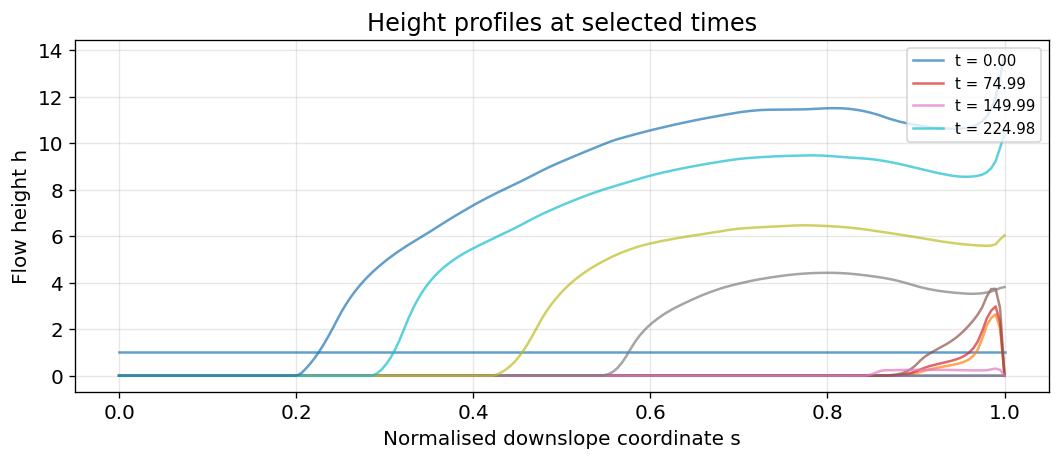

In [5]:
n_plot = max(1, n_snapshots // 10)   # every n-th snapshot

fig, ax = plt.subplots(figsize=(9, 4))
for i in range(0, n_snapshots, n_plot):
    lbl = f't = {time_arr[i]:.2f}' if i % (n_plot * 3) == 0 else ''
    ax.plot(x, h_snaps[i], alpha=0.7, linewidth=1.5, label=lbl)

ax.set_xlabel('Normalised downslope coordinate s')
ax.set_ylabel('Flow height h')
ax.set_title('Height profiles at selected times')
ax.legend(fontsize=9, loc='upper right')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Velocity Profiles (Final Snapshot)

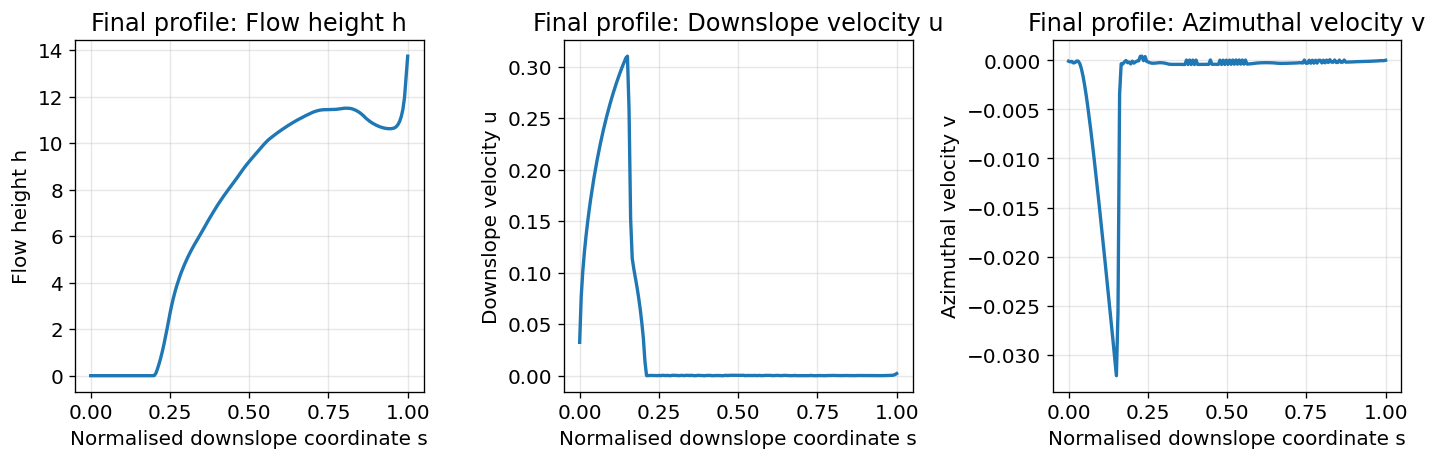

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
datasets = [(h_snaps, 'Flow height h'),
            (u_snaps, 'Downslope velocity u'),
            (v_snaps, 'Azimuthal velocity v')]

for ax, (data, label) in zip(axes, datasets):
    ax.plot(x, data[-1], linewidth=2)
    ax.set_xlabel('Normalised downslope coordinate s')
    ax.set_ylabel(label)
    ax.set_title(f'Final profile: {label}')
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## Spin Rate and Mass Evolution

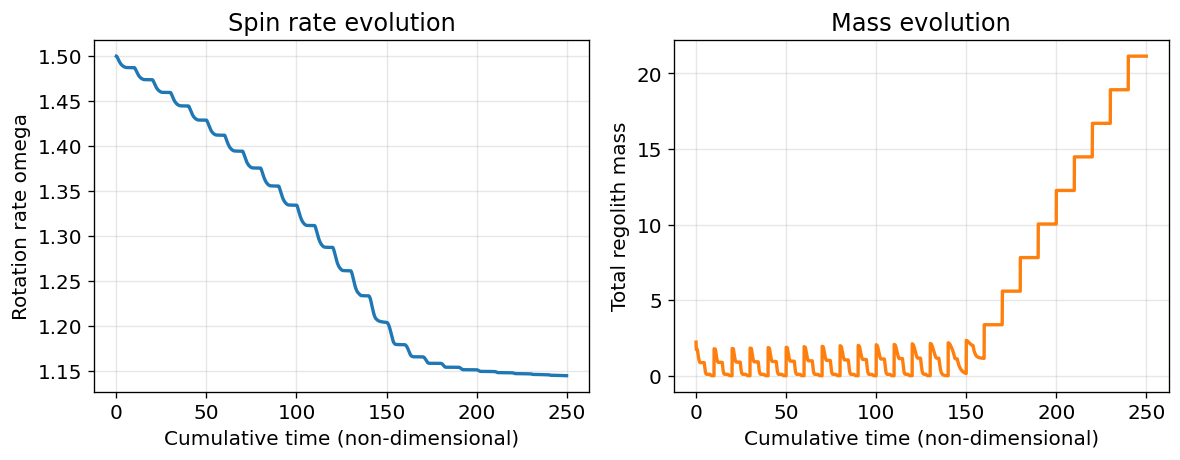

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].plot(time_arr, omega_arr, linewidth=2)
axes[0].set_xlabel('Cumulative time (non-dimensional)')
axes[0].set_ylabel('Rotation rate omega')
axes[0].set_title('Spin rate evolution')
axes[0].grid(alpha=0.3)

axes[1].plot(time_arr, mass_arr, linewidth=2, color='C1')
axes[1].set_xlabel('Cumulative time (non-dimensional)')
axes[1].set_ylabel('Total regolith mass')
axes[1].set_title('Mass evolution')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## Kinetic Energy Evolution

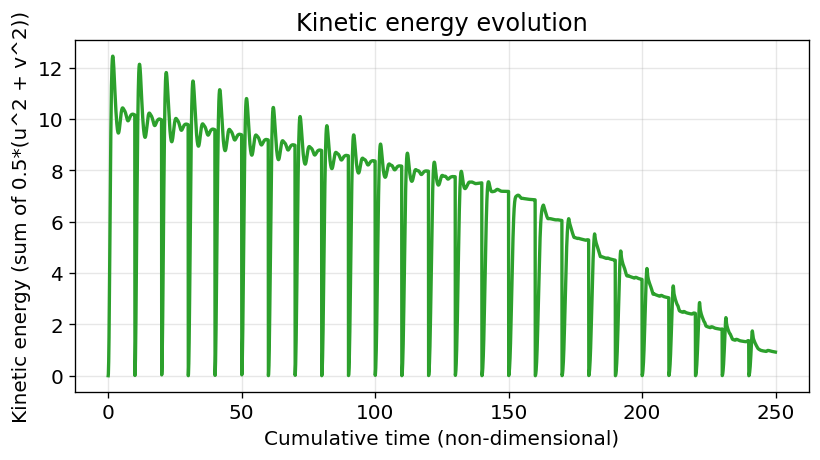

In [8]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(time_arr, ke_arr, linewidth=2, color='C2')
ax.set_xlabel('Cumulative time (non-dimensional)')
ax.set_ylabel('Kinetic energy (sum of 0.5*(u^2 + v^2))')
ax.set_title('Kinetic energy evolution')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()